In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')

총 샘플 수: 1000
이상치 비율: 5.00%
--- Local Outlier Factor ---
AUC-ROC: 0.9027
AUC-PR: 0.5483
--- Isolation Forest ---
AUC-ROC: 0.9519
AUC-PR: 0.8497

--- 이상치 점수 데이터프레임 (상위 5개 행) ---
   Feature 1  Feature 2 True Anomaly  LOF_Score  IF_Score
0   1.678904   1.301808       Normal   1.411398  0.569583
1  -0.058931  -0.116921       Normal   0.985921  0.378325
2  -0.275276  -0.632229       Normal   1.031424  0.395661
3   0.474707  -1.377101       Normal   1.026096  0.458447
4  -0.459261  -0.004466       Normal   0.986182  0.388000

DataFrame saved to anomaly_scores_comparison.csv


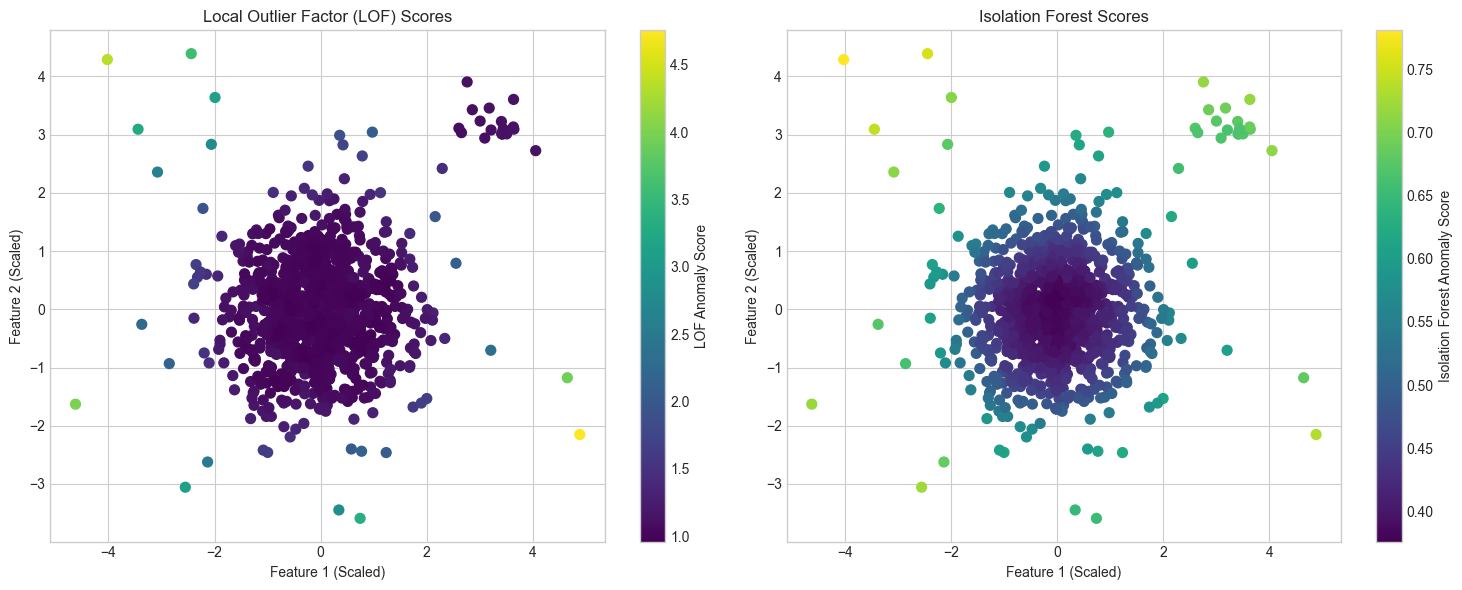

In [2]:

## 1. 라이브러리 임포트

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # 시각화를 위해 추가
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc,roc_curve

# 시각화 스타일 설정 (선택 사항)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. 데이터 생성 및 스케일링

def generate_anomaly_data(n_samples=1000, contamination=0.05, random_state=42):
    """정상 데이터와 3가지 유형의 이상치 데이터를 생성합니다."""
    np.random.seed(random_state)

    # 정상 데이터 (95%)
    n_normal = int(n_samples * (1 - contamination))
    normal_data = np.random.multivariate_normal(mean=[0, 0], cov=[[1, 0], [0, 1]], size=n_normal)

    # 이상치 데이터 (5%)
    n_anomalies = n_samples - n_normal
    n_type1 = n_anomalies // 3
    n_type2 = n_anomalies // 3
    n_type3 = n_anomalies - n_type1 - n_type2

    # 1. Extreme anomalies (극단적 이상치)
    extreme_anomalies = np.random.uniform(low=-6, high=6, size=(n_type1, 2))

    # 2. Cluster anomalies (군집형 이상치)
    cluster_anomalies = np.random.multivariate_normal(mean=[4, 4], cov=[[0.1, 0], [0, 0.1]], size=n_type2)

    # 3. Random anomalies (무작위 이상치)
    random_anomalies = np.random.uniform(low=-4, high=4, size=(n_type3, 2))

    # 데이터 결합(0:정상,1:이상치)
    X = np.vstack([normal_data, extreme_anomalies, cluster_anomalies, random_anomalies])
    y = np.array([0] * n_normal + [1] * n_anomalies) # 0: Normal, 1: Anomaly

    # 데이터 섞기
    idx = np.random.permutation(n_samples)
    X, y = X[idx], y[idx]

    return X, y

# 데이터 생성
X, y = generate_anomaly_data(n_samples=1000, contamination=0.05, random_state=42)

# 데이터 스케일링 (정규화)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"총 샘플 수: {len(X)}")
print(f"이상치 비율: {np.mean(y) * 100:.2f}%")


## 3. 모델 정의 및 학습

CONTAMINATION = 0.05
LOF_NEIGHBORS = 20

models = {
    "Local Outlier Factor": LocalOutlierFactor(n_neighbors=LOF_NEIGHBORS, contamination=CONTAMINATION, novelty=True),
    "Isolation Forest": IsolationForest(contamination=CONTAMINATION, random_state=512)
}

results = {}

for name, model in models.items():
    # 모델 학습
    model.fit(X_scaled)

    # 이상치 점수 계산 (점수가 높을수록 이상치)
    if name == "Local Outlier Factor":
        # LOF의 score_samples는 음의 LOF 점수를 반환하므로, 양수로 변환
        scores = -model.score_samples(X_scaled)
    else: # Isolation Forest
        # Isolation Forest의 score_samples는 점수가 낮을수록 이상치이므로, 음수로 변환
        scores = -model.score_samples(X_scaled)

    # 성능 평가
    auc_roc = roc_auc_score(y, scores)
    precision, recall, _ = precision_recall_curve(y, scores)
    auc_pr = auc(recall, precision)

    # 결과 저장
    results[name] = {'scores': scores, 'auc_roc': auc_roc, 'auc_pr': auc_pr}

    print(f"--- {name} ---")
    print(f"AUC-ROC: {auc_roc:.4f}")
    print(f"AUC-PR: {auc_pr:.4f}")


## 4. 원본 데이터에 스코어링 결과 결합 및 저장 (사용자 요청 부분)

# 데이터프레임 생성
data = {
    'Feature 1': X_scaled[:, 0],
    'Feature 2': X_scaled[:, 1],
    'True Anomaly': y,
    'LOF_Score': results['Local Outlier Factor']['scores'],
    'IF_Score': results['Isolation Forest']['scores']
}

df_results = pd.DataFrame(data)

# 'True Anomaly' 컬럼 값 변경 (0 -> Normal, 1 -> Anomaly)
df_results['True Anomaly'] = df_results['True Anomaly'].astype('category').cat.rename_categories({0: 'Normal', 1: 'Anomaly'})

# 데이터프레임 상위 5개 행 출력
print("\n--- 이상치 점수 데이터프레임 (상위 5개 행) ---")
print(df_results.head())

# CSV 파일로 저장
df_results.to_csv('anomaly_scores_comparison.csv', index=False)
print("\nDataFrame saved to anomaly_scores_comparison.csv")


## 5. 결과 시각화 및 비교 분석 (추가 시각화 코드)

plt.figure(figsize=(15, 6))

# 5-1. LOF Score 시각화
plt.subplot(1, 2, 1)
scatter_lof = plt.scatter(df_results['Feature 1'], df_results['Feature 2'], c=df_results['LOF_Score'], cmap='viridis', s=50)
plt.colorbar(scatter_lof, label='LOF Anomaly Score')
plt.title('Local Outlier Factor (LOF) Scores')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')

# 5-2. Isolation Forest Score 시각화
plt.subplot(1, 2, 2)
scatter_if = plt.scatter(df_results['Feature 1'], df_results['Feature 2'], c=df_results['IF_Score'], cmap='viridis', s=50)
plt.colorbar(scatter_if, label='Isolation Forest Anomaly Score')
plt.title('Isolation Forest Scores')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')

plt.tight_layout()
plt.show()

# 분석
#
# 이상치 탐지 결과를 시각화와 정량적 지표를 사용하여 이상치를 탐지하고 성능을 비교 분석했습니다.
#
# - Local Outlier Factor (LOF): 데이터의 '지역적 밀도'를 기반으로 이상치를 탐지합니다. 시각화 결과에서 볼 수 있듯이, 정상 데이터 군집에서 살짝 벗어난 점들이나 밀도가 낮은 지역에 있는 점들에 대해 높은 이상치 점수를 부여하는 경향이 있습니다.
#
# - Isolation Forest: 데이터를 무작위로 분할하여 '격리하기 쉬운' 정도를 기준으로 이상치를 탐지합니다. 전역적인 관점에서 동떨어진 점들(극단적 이상치)에 대해 매우 높은 점수를 부여하며, 계산 속도가 빠르다는 장점이 있습니다.
#
# 실제 문제에서는 데이터의 분포와 이상치의 특성에 따라 더 적합한 모델이 달라질 수 있습니다.
# - 만약 데이터에 밀도가 다른 여러 군집이 존재하고, 각 군집에 대한 '로컬 이상치'를 찾는 것이 중요하다면 **LOF**가 더 좋은 선택이 될 수 있습니다.
# - 반면, 데이터가 매우 크고 고차원이며, 전반적인 분포에서 벗어난 '글로벌 이상치'를 빠르게 찾아내야 한다면 **Isolation Forest**가 더 효율적일 수 있습니다.
#
# 따라서 실제 문제에 적용할 때는 데이터의 특성을 먼저 파악하고, 여러 모델을 테스트하여 가장 적합한 알고리즘을 선택하는 것이 중요합니다.